<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/Los_cimientos_de_redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
#!pip install keras keras-hub --upgrade -q

In [77]:
#import os
#os.environ["KERAS_BACKEND"] = "tensorflow"

##**La primera mirada a redes neuronales**

In [78]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [79]:
train_images.shape

(60000, 28, 28)

In [80]:
len(train_labels)

60000

In [81]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [82]:
test_images.shape

(10000, 28, 28)

In [83]:
len(test_labels)

10000

In [84]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [85]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [86]:
print(model)

<Sequential name=sequential_1, built=False>


In [87]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [88]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [89]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8681 - loss: 0.4653
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9660 - loss: 0.1201
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9791 - loss: 0.0695
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9856 - loss: 0.0501
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9899 - loss: 0.0360


In [90]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([6.3541609e-07, 2.6070101e-08, 1.1069903e-05, 3.1912164e-04,
       6.4358206e-11, 3.0709666e-07, 1.7865724e-12, 9.9966240e-01,
       1.8976660e-06, 4.5364413e-06], dtype=float32)

In [91]:
test_digits.shape

(10, 784)

In [92]:
type(test_digits)

numpy.ndarray

In [93]:
predictions[0].argmax()

np.int64(7)

In [94]:
predictions[0][7]

np.float32(0.9996624)

In [95]:
test_labels[0]

np.uint8(7)

In [96]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9745 - loss: 0.0740
test_acc: 0.9785000085830688


##**Representacion de los datos para redes neuronales**

In [97]:
import numpy as np
x = np.array(12)
x

array(12)

In [98]:
x.ndim

0

In [99]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [100]:
print(x.ndim)
print(x.shape)

1
(5,)


In [101]:
x = np.array([[5, 78, 2, 34, 0],
             [6, 79, 3, 35, 1],
             [7, 80, 4, 36, 2]])
x

array([[ 5, 78,  2, 34,  0],
       [ 6, 79,  3, 35,  1],
       [ 7, 80,  4, 36,  2]])

In [102]:
print(x.ndim)
print(x.shape)

2
(3, 5)


In [103]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
print(x.ndim)
print(x.shape)

3
(3, 3, 5)


###**intepretación de atributos**

In [104]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [105]:
train_images.ndim

3

In [106]:
train_images.shape

(60000, 28, 28)

In [107]:
train_images.dtype

dtype('uint8')

60000


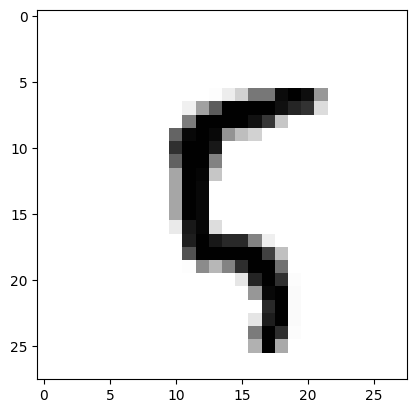

In [108]:
import matplotlib.pyplot as plt

print(len(train_images))
digit = train_images[100]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [109]:
train_labels[100]

np.uint8(5)

###**manipulacion de tensores usando numpy**

In [110]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [111]:
my_slice = train_images[10:100, :, :]
my_slice.shape

(90, 28, 28)

In [112]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [113]:
my_slice = train_images[:, 14:, 14:]
my_slice.shape

(60000, 14, 14)

In [114]:
my_slice = train_images[:, 7:-7, 7:-7]
my_slice.shape

(60000, 14, 14)

###**Lotes o batches**

In [115]:
batch = train_images[:128]
print(batch.shape)

(128, 28, 28)


In [116]:
batch = train_images[128:256]
print(batch.shape)

(128, 28, 28)


In [117]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]
print(batch.shape)

(128, 28, 28)


##**Operaciones con tensores**

###**Operaciones elemento a elemento**

In [118]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

In [119]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

In [120]:
import time

#modifiquemos la matriz
x = np.random.random((20, 100))
print(x.shape)
y = np.random.random((20, 100))
print(y.shape)

t0 = time.time()
for _ in range(1000):
    z = x + y
    z = np.maximum(z, 0.0)
print("Took: {0:.2f} s".format(time.time() - t0))

(20, 100)
(20, 100)
Took: 0.01 s


In [121]:
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 3.29 s


###**Broadcasting**

#### Concepto de Broadcasting en Redes Neuronales

---

#### 1. El problema: La rigidez matemática
Normalmente, si quieres sumar dos matrices, el álgebra lineal estricta dice que ambas deben tener exactamente la misma forma (ej. $2 \times 2$ con $2 \times 2$).

Sin embargo, en el deep learning, es muy común querer sumarle un vector de **sesgo (bias)** a toda una matriz de datos. Hacer esto manualmente implicaría copiar el vector muchas veces para "rellenar" una matriz del mismo tamaño, lo cual desperdicia memoria.

#### 2. La solución: El Broadcasting
El broadcasting "estira" virtualmente la dimensión más pequeña para que coincida con la más grande, **sin duplicar los datos en la memoria**.

#### Las reglas de oro
Para que dos tensores sean compatibles, se comparan sus dimensiones de **derecha a izquierda**:
1.  **Igualdad:** Las dimensiones son iguales.
2.  **Unidad:** Una de las dimensiones es $1$.

Si una dimensión es $1$, esa dimensión se "expande" para alcanzar el tamaño de la otra.

---

#### 3. Ejemplo práctico

Imagina que tienes una matriz de datos **A** (3 muestras) y un vector de sesgo **b**:

* **Matriz A ($3 \times 3$):** Puntuaciones de 3 categorías.
* **Vector b ($1 \times 3$):** Un ajuste para cada categoría.

#### Operación original:
$$
\begin{bmatrix} 10 & 20 & 30 \\ 10 & 20 & 30 \\ 10 & 20 & 30 \end{bmatrix} + \begin{bmatrix} 1 & 2 & 3 \end{bmatrix}
$$

#### Lo que hace el Broadcasting internamente:
El vector $b$ se comporta virtualmente como si fuera:
$$
\begin{bmatrix} 1 & 2 & 3 \\ 1 & 2 & 3 \\ 1 & 2 & 3 \end{bmatrix}
$$

#### Resultado final:
$$
\begin{bmatrix} 11 & 22 & 33 \\ 11 & 22 & 33 \\ 11 & 22 & 33 \end{bmatrix}
$$


In [122]:
import numpy as np

X = np.random.random((32, 10))
y_raw = np.random.random((10,))
print(X.shape)
print(y_raw.shape)

(32, 10)
(10,)


In [123]:
y = np.expand_dims(y_raw, axis=0)
print(y.shape)

(1, 10)


In [124]:
Y = np.tile(y, (32, 1))
print(Y.shape)

(32, 10)


In [125]:
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

In [126]:
x = naive_add_matrix_and_vector(X, y_raw)
print(X.shape)
print(y_raw.shape)
print(x.shape)

(32, 10)
(10,)
(32, 10)


In [127]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10))
z = np.maximum(x, y)
print(x.shape)
print(y.shape)
print(z.shape)

(64, 3, 32, 10)
(32, 10)
(64, 3, 32, 10)


In [128]:
x = np.random.random((3, 3))
print(x)
print("-----")
y = np.random.random((3))
print(y)
print("-----")
z = np.maximum(x, y)
print(z)

[[0.73650669 0.75433086 0.39792546]
 [0.12493688 0.41484678 0.4966609 ]
 [0.11534317 0.33550346 0.23588555]]
-----
[0.06136649 0.84481648 0.26888822]
-----
[[0.73650669 0.84481648 0.39792546]
 [0.12493688 0.84481648 0.4966609 ]
 [0.11534317 0.84481648 0.26888822]]


###**Producto punto**

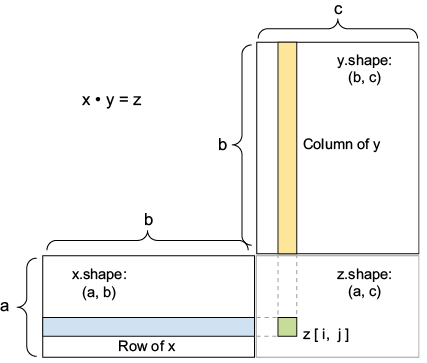

In [129]:
x = np.random.random((32,))
y = np.random.random((32,))

z = np.matmul(x, y)
z = x @ y

In [130]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

In [131]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

In [132]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

In [133]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

###**Remodelar o reshape de tensores**

In [134]:
train_images = train_images.reshape((60000, 28 * 28))
print(train_images.shape)

(60000, 784)


In [135]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

(3, 2)

In [137]:
x = x.reshape((6, 1))
print(x.shape)
print(x)

(6, 1)
[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]]


In [139]:
x = x.reshape((2, 3))
print(x.shape)
print(x)

(2, 3)
[[0. 1. 2.]
 [3. 4. 5.]]


In [141]:
#Matriz transpuesta
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

(20, 300)

###**Interpretación geometrica de las operaciones de los tensores**

In [143]:
#colocar imagenes
#esto permite entender como cambia la representación de los datos. Son operaciones
#entre vectores.

##**El algoritmo de optimización: el gradiente descendiente**

```
# output = relu(matmul(input, W) + b)
```
Los pesos o parametros (W) y la neurona de sesgo (b).

Existe una iniciación aleatoria.

El entrenamiento es en realidad el siguiente algoritmo.

### Pasos del Ciclo de Entrenamiento (Training Loop)

1. **Obtener los datos:** Extraer un lote (batch) de muestras de entrenamiento **x** y sus correspondientes etiquetas reales **y_true**.

2. **Pase hacia adelante (Forward pass):** Ejecutar el modelo sobre **x** para obtener las predicciones **y_pred**.

3. **Calcular la pérdida (Loss):** Calcular la pérdida del modelo en el lote, una medida del desajuste entre **y_pred** y **y_true**.

4. **Actualizar los pesos:** Actualizar todos los pesos del modelo de manera que se reduzca ligeramente la pérdida en este lote.